In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_csv("C:/Users/ASUS/Desktop/FBS/Data science/Dataset/Default.csv")
df.head()

,default,student,balance,income
0,No,No,729.526495,44361.62507
1,No,Yes,817.180407,12106.13470
2,No,No,1073.549164,31767.13895
3,No,No,529.250605,35704.49394
4,No,No,785.655883,38463.49588


In [35]:
df.tail()

,default,student,balance,income
9995,No,No,711.555020,52992.37891
9996,No,No,757.962918,19660.72177
9997,No,No,845.411989,58636.15698
9998,No,No,1569.009053,36669.11236
9999,No,Yes,200.922183,16862.95232


In [36]:
df.describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462905
50%,823.636973,34552.644800
75%,1166.308387,43807.729275
max,2654.322576,73554.233500


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   default  10000 non-null  object 
 1   student  10000 non-null  object 
 2   balance  10000 non-null  float64
 3   income   10000 non-null  float64
dtypes: float64(2), object(2)
memory usage: 312.6+ KB


In [38]:
df.shape

(10000, 4)

In [39]:
df.columns

Index(['default', 'student', 'balance', 'income'], dtype='object')

In [40]:
df.isnull().sum()

default    0
student    0
balance    0
income     0
dtype: int64

In [41]:
df.duplicated().sum()

np.int64(0)

In [42]:
df['default'].unique()

array(['No', 'Yes'], dtype=object)

In [43]:
df['default'].value_counts()

default
No     9667
Yes     333
Name: count, dtype: int64

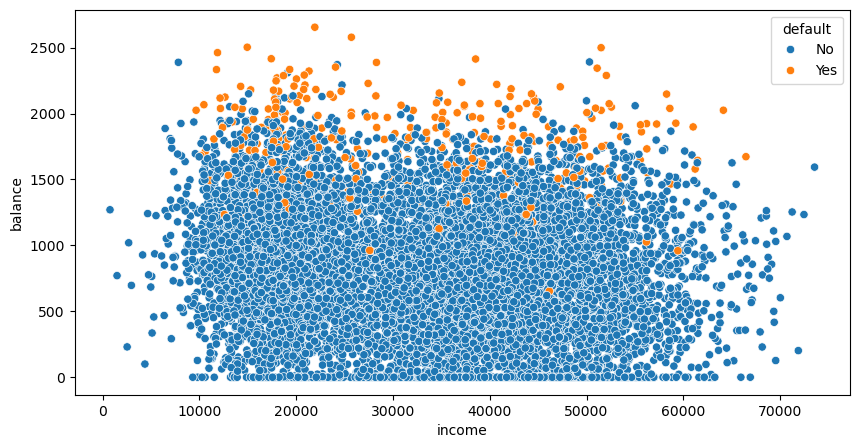

In [44]:
plt.figure(figsize= (10,5))
sns.scatterplot(data = df,x = 'income',y = 'balance',hue = 'default')
plt.show()

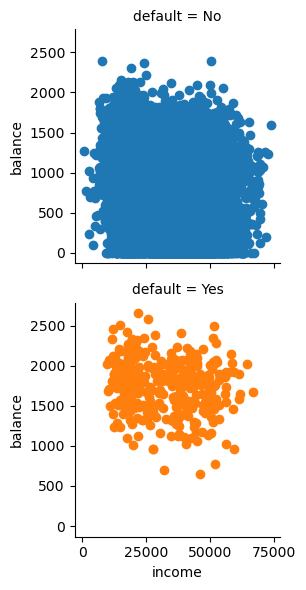

In [45]:
sns.FacetGrid(df,hue ='default',row = 'default').map(plt.scatter,'income','balance')

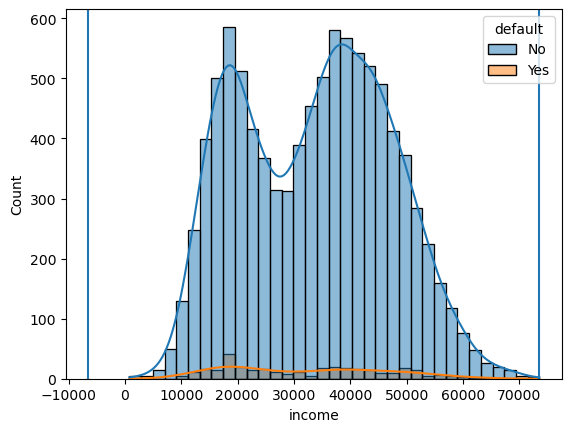

In [46]:
sns.histplot(data = df,x = 'income',hue ='default',kde = True)
plt.axvline(df['income'].mean() + df['income'].std()*3)
plt.axvline(df['income'].mean() - df['income'].std()*3)

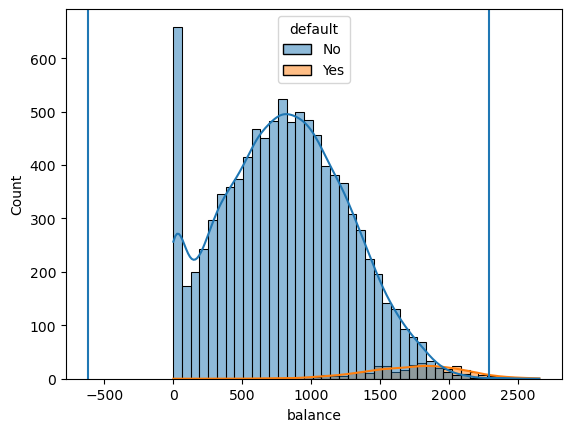

In [47]:
sns.histplot(data = df,x = 'balance',hue ='default',kde = True)
plt.axvline(df['balance'].mean() + df['balance'].std()*3)
plt.axvline(df['balance'].mean() - df['balance'].std()*3)

<Axes: >

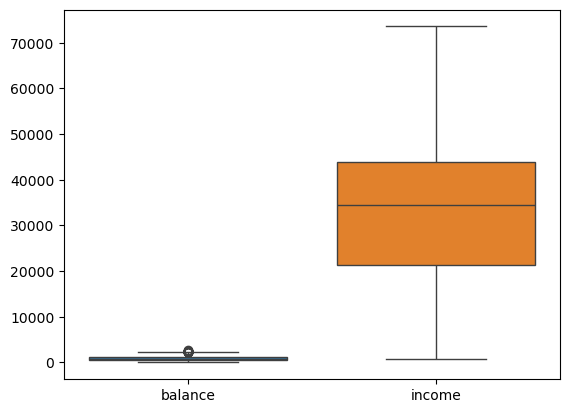

In [48]:
sns.boxplot(data = df)

<Axes: xlabel='default', ylabel='income'>

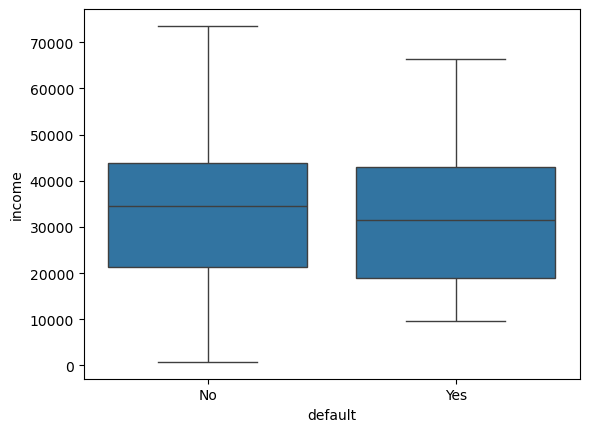

In [49]:
sns.boxplot(data = df,x= 'default',y = 'income')

<Axes: xlabel='default', ylabel='balance'>

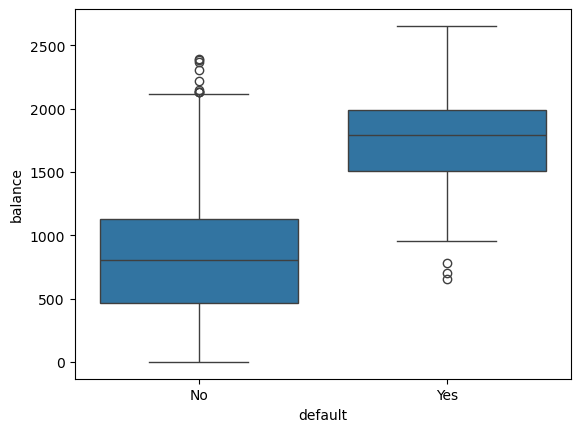

In [50]:
sns.boxplot(data = df,x= 'default',y = 'balance')

In [51]:
q1 = df['balance'].quantile(0.25)
q1

np.float64(481.73110505)

In [52]:
q3 = df['balance'].quantile(0.75)
q3

np.float64(1166.30838675)

In [53]:
iqr = q3 - q1
iqr

np.float64(684.5772817)

In [54]:
upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr

In [55]:
df[df['income']> upper_bound]

,default,student,balance,income
0,No,No,729.526495,44361.62507
1,No,Yes,817.180407,12106.13470
2,No,No,1073.549164,31767.13895
3,No,No,529.250605,35704.49394
4,No,No,785.655883,38463.49588
...,...,...,...,...
9995,No,No,711.555020,52992.37891
9996,No,No,757.962918,19660.72177
9997,No,No,845.411989,58636.15698
9998,No,No,1569.009053,36669.11236


<Axes: >

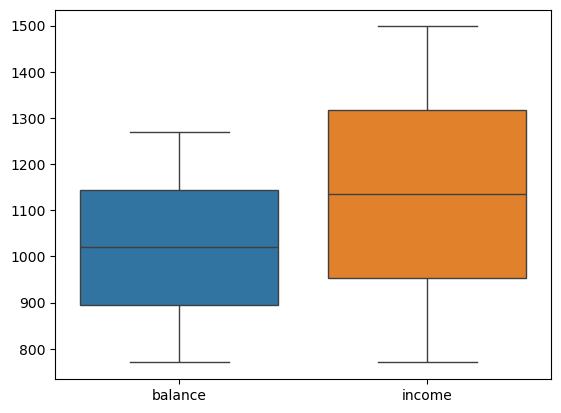

In [56]:
df2 = df[(df['income'] >= lower_bound) & (df['income'] <= upper_bound)]
sns.boxplot(data = df2)

In [57]:
df_numeric = df.drop(columns=['default', 'student'])
df_numeric

,balance,income
0,729.526495,44361.62507
1,817.180407,12106.13470
2,1073.549164,31767.13895
3,529.250605,35704.49394
4,785.655883,38463.49588
...,...,...
9995,711.555020,52992.37891
9996,757.962918,19660.72177
9997,845.411989,58636.15698
9998,1569.009053,36669.11236


<Axes: >

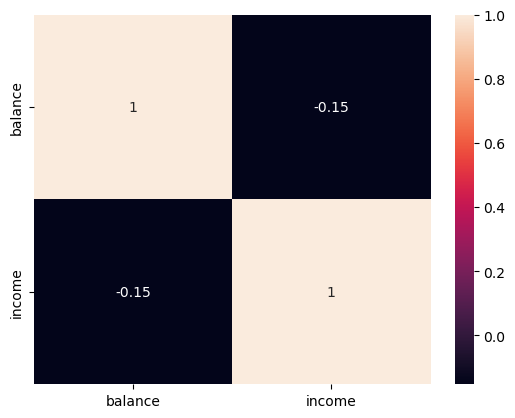

In [58]:
sns.heatmap(df_numeric.corr(),annot = True)

In [59]:
df = pd.get_dummies(df, columns=['default', 'student'],dtype ='int')
df.head()

,balance,income,default_No,default_Yes,student_No,student_Yes
0,729.526495,44361.62507,1,0,1,0
1,817.180407,12106.13470,1,0,0,1
2,1073.549164,31767.13895,1,0,1,0
3,529.250605,35704.49394,1,0,1,0
4,785.655883,38463.49588,1,0,1,0


In [60]:
X = df.drop(['default_No', 'default_Yes'], axis=1)
y = df[['default_No', 'default_Yes']]

In [61]:
X.head()

,balance,income,student_No,student_Yes
0,729.526495,44361.62507,1,0
1,817.180407,12106.13470,0,1
2,1073.549164,31767.13895,1,0
3,529.250605,35704.49394,1,0
4,785.655883,38463.49588,1,0


In [65]:
X.corr()

,balance,income,student_No,student_Yes
balance,1.000000,-0.152243,-0.203578,0.203578
income,-0.152243,1.000000,0.753985,-0.753985
student_No,-0.203578,0.753985,1.000000,-1.000000
student_Yes,0.203578,-0.753985,-1.000000,1.000000


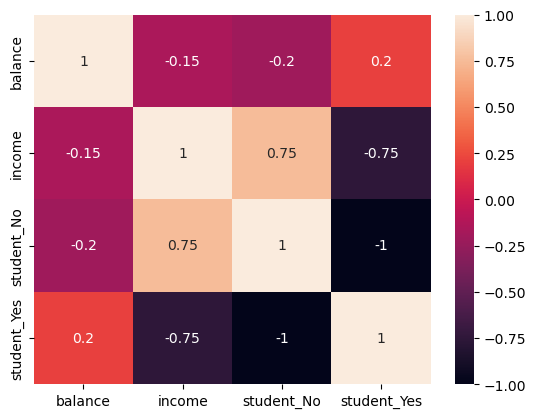

In [69]:
sns.heatmap(X.corr(), annot=True)
plt.show()

In [62]:
y.head()

,default_No,default_Yes
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0


In [63]:
from sklearn.model_selection import train_test_split

In [64]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2,random_state=10)